In [ ]:
from google.colab import drive
drive.flush_and_unmount()
import os
os.system('rm -rf /content/drive/*') # Ensure the directory is empty
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Dataset_converted"

# Count images per class
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        total_images = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        print(f"{class_name}: {total_images} images")


fresh: 1000 images
infected: 1000 images


In [ ]:
import os
import random
import shutil

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Dataset_converted"
output_path = "/content/drive/MyDrive/Chickpea Resources/Dataset_split"

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

random.seed(42)

# =========================
# 1️⃣ CREATE FOLDERS
# =========================
for split in ['train', 'val', 'test']:
    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# =========================
# 2️⃣ SPLIT DATA (STRATIFIED)
# =========================
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = round(total * train_ratio)
    val_end = train_end + round(total * val_ratio)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    # Copy files
    for img in train_files:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'train', class_name, img))

    for img in val_files:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'val', class_name, img))

    for img in test_files:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'test', class_name, img))

# =========================
# 3️⃣ COUNT FINAL DATASET
# =========================

splits = ['train', 'val', 'test']

print("\n📊 FINAL DATASET SUMMARY\n")

for split in splits:
    split_path = os.path.join(output_path, split)
    total_count = 0

    for class_name in os.listdir(split_path):
        class_folder = os.path.join(split_path, class_name)

        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])

            total_count += count

    print(f"{split.upper()} total images: {total_count}")


📊 FINAL DATASET SUMMARY

TRAIN total images: 1600
VAL total images: 200
TEST total images: 200


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random

train_path = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/train"
aug_output = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"

target_per_class = 3000

# Create output folders
for class_name in os.listdir(train_path):
    os.makedirs(os.path.join(aug_output, class_name), exist_ok=True)

# Augmentation setup
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# =========================
# AUGMENT EACH CLASS
# =========================
for class_name in os.listdir(train_path):

    class_folder = os.path.join(train_path, class_name)
    save_folder = os.path.join(aug_output, class_name)

    images = [
        img for img in os.listdir(class_folder)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    count = 0

    # First copy original images
    for img_name in images:
        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))

        cv2.imwrite(os.path.join(save_folder, f"orig_{count}.jpg"), img)
        count += 1

    # Generate augmented images until 3000 reached
    i = 0
    while count < target_per_class:

        img_name = random.choice(images)
        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        img = np.expand_dims(img, axis=0)

        for batch in datagen.flow(img, batch_size=1):
            aug_img = batch[0].astype(np.uint8)

            cv2.imwrite(
                os.path.join(save_folder, f"aug_{count}.jpg"),
                aug_img
            )

            count += 1
            break

    print(f"{class_name}: Completed -> {count} images")

print("🔥 Augmentation to 3000 per class completed")

fresh: Completed -> 3000 images
infected: Completed -> 3000 images
🔥 Augmentation to 3000 per class completed


In [ ]:
import os

aug_output = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"

total_images = 0

print("\n📊 AUGMENTED DATASET SHAPE\n")

for class_name in os.listdir(aug_output):
    class_path = os.path.join(aug_output, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        total_images += count
        print(f"{class_name}: {count} images")

print("\nTOTAL AUGMENTED IMAGES:", total_images)


📊 AUGMENTED DATASET SHAPE

fresh: 3000 images
infected: 3000 images

TOTAL AUGMENTED IMAGES: 6000


In [ ]:
import os

train_path = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
test_path = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

train_files = []
test_files = []

for c in os.listdir(train_path):
    for f in os.listdir(os.path.join(train_path, c)):
        train_files.append(f)

for c in os.listdir(test_path):
    for f in os.listdir(os.path.join(test_path, c)):
        test_files.append(f)

intersection = set(train_files).intersection(set(test_files))

print("Overlapping files:", len(intersection))

Overlapping files: 0


Found 6000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 68s 284ms/step - accuracy: 0.9513 - loss: 0.1942 - val_accuracy: 0.5000 - val_loss: 3.1400
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 206ms/step - accuracy: 0.9833 - loss: 0.0744 - val_accuracy: 0.9850 - val_loss: 0.0773
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - accuracy: 0.9865 - loss: 0.0579 - val_accuracy: 0.9850 - val_loss: 0.0239
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 204ms/step - accuracy: 0.9900 - loss: 0.0408 - val_accuracy: 0.9950 - val_loss: 0.0227
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.9913 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 210ms/step - accuracy: 0.9938 - loss: 0.0236 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.9930 - loss: 0.0284 - val_accuracy: 0.9900 - val_loss: 0.0412
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 239ms/step - accuracy: 0.9925 - loss: 0

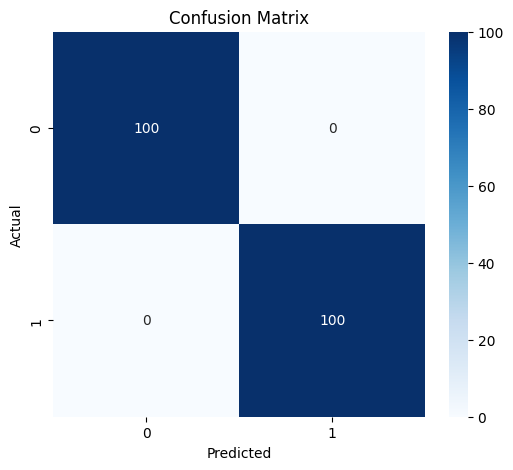

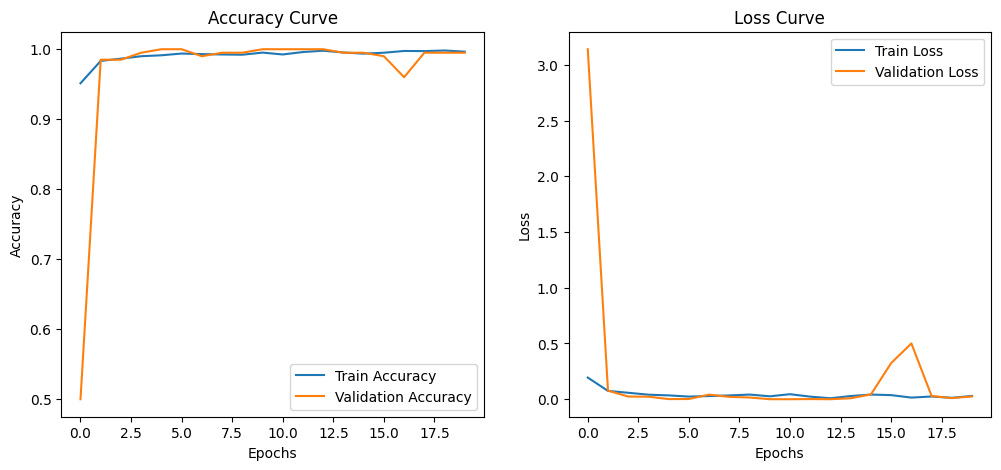

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# DATA PATHS
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

# =========================
# DATA GENERATOR
# =========================
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# =========================
# CNN MODEL
# =========================
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAINING
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# =========================
# TEST EVALUATION
# =========================
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int)

y_true = test_data.classes

accuracy = accuracy_score(y_true, y_pred)
print("\nTest Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

Dataset shape: (1600, 224, 224, 3) (1600,)

🔥 Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.9359 - loss: 0.3620 - val_accuracy: 0.8438 - val_loss: 0.3845
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9805 - loss: 0.1248 - val_accuracy: 0.8969 - val_loss: 0.3001
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9883 - loss: 0.1183 - val_accuracy: 0.8469 - val_loss: 0.3848
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9883 - loss: 0.0651 - val_accuracy: 0.6687 - val_loss: 1.5075
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9930 - loss: 0.0399 - val_accuracy: 0.8938 - val_loss: 0.4754
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9930 - loss: 0.0429 - val_accuracy: 0.9219 - val_loss: 0.4609
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9898 - loss: 0.0396 - val_accuracy: 0.8687 - val_loss: 1.1964
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9187 -

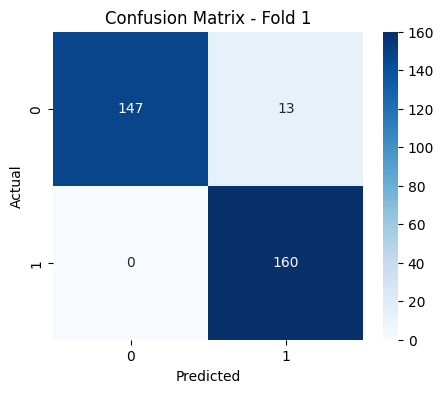

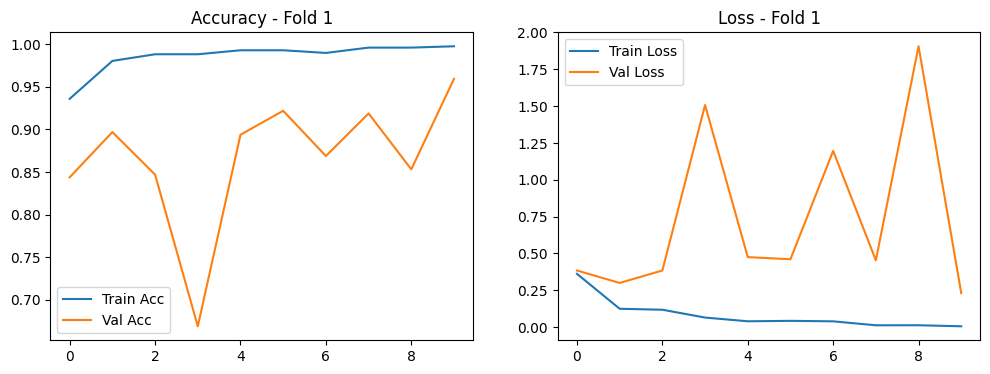


🔥 Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9250 - loss: 0.4154 - val_accuracy: 0.5000 - val_loss: 0.8463
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9852 - loss: 0.0987 - val_accuracy: 0.7719 - val_loss: 0.4376
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9875 - loss: 0.0502 - val_accuracy: 0.8625 - val_loss: 0.3047
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9953 - loss: 0.0231 - val_accuracy: 0.6219 - val_loss: 1.0081
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9961 - loss: 0.0228 - val_accuracy: 0.6656 - val_loss: 1.1185
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9961 - loss: 0.0094 - val_accuracy: 0.6375 - val_loss: 1.6889
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9984 - loss: 0.0068 - val_accuracy: 0.5562 - val_loss: 3.3943
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.6750 -

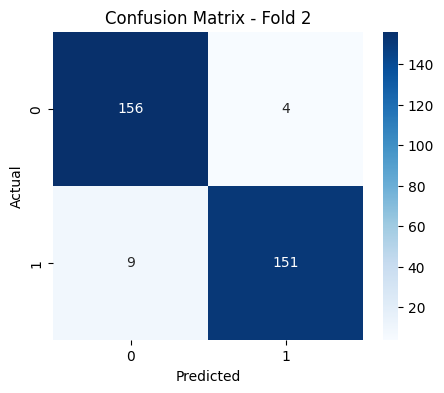

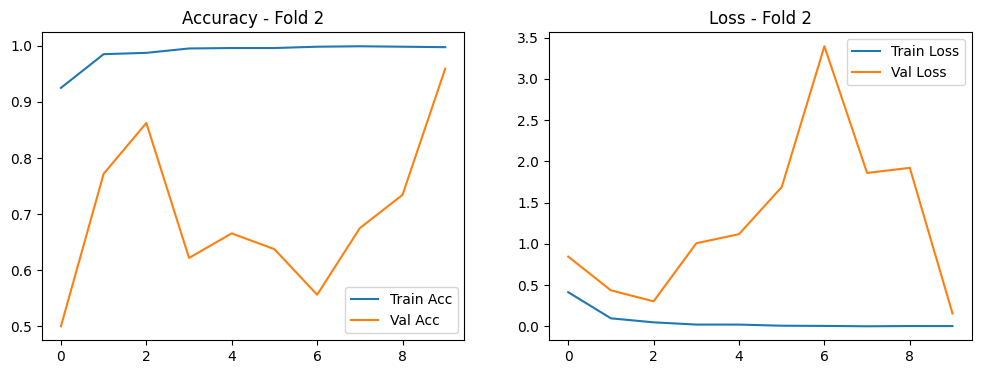


🔥 Fold 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9352 - loss: 0.3259 - val_accuracy: 0.5000 - val_loss: 1.9512
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9820 - loss: 0.0832 - val_accuracy: 0.5000 - val_loss: 2.1369
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9898 - loss: 0.0528 - val_accuracy: 0.6687 - val_loss: 1.0558
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9906 - loss: 0.0585 - val_accuracy: 0.8500 - val_loss: 0.4698
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9898 - loss: 0.0429 - val_accuracy: 0.8125 - val_loss: 0.7019
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9906 - loss: 0.0514 - val_accuracy: 0.9031 - val_loss: 0.3187
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9961 - loss: 0.0263 - val_accuracy: 0.9062 - val_loss: 0.3016
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9344 -

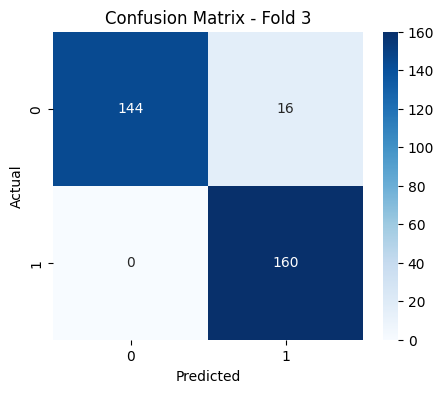

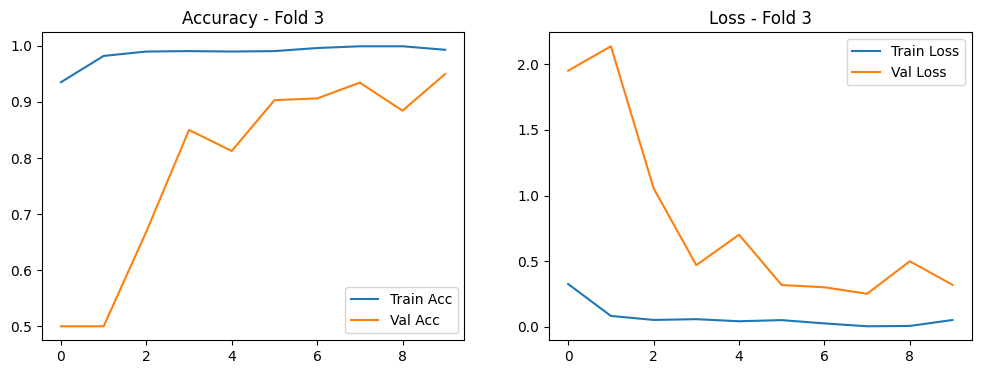


🔥 Fold 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9445 - loss: 0.3259 - val_accuracy: 0.5000 - val_loss: 2.0244
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9812 - loss: 0.1033 - val_accuracy: 0.5000 - val_loss: 2.5913
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9844 - loss: 0.0903 - val_accuracy: 0.5000 - val_loss: 4.3132
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9867 - loss: 0.0852 - val_accuracy: 0.7188 - val_loss: 0.8928
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9930 - loss: 0.0477 - val_accuracy: 0.7625 - val_loss: 0.5853
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9937 - loss: 0.0339 - val_accuracy: 0.8250 - val_loss: 0.5353
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9969 - loss: 0.0257 - val_accuracy: 0.8781 - val_loss: 0.3411
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9945 - loss: 0.0267 - val_accuracy: 0.9281 -

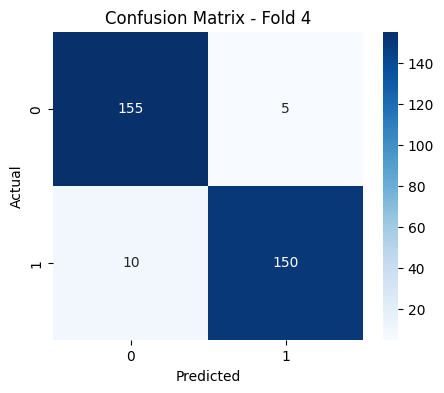

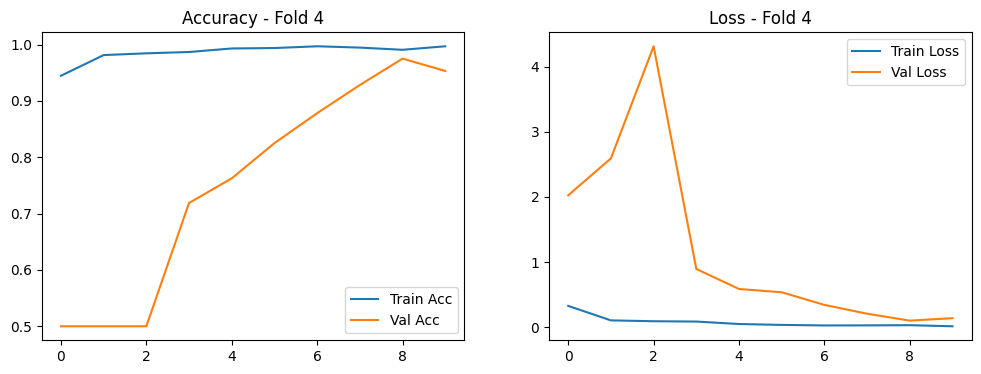


🔥 Fold 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.9312 - loss: 0.3773 - val_accuracy: 0.5031 - val_loss: 0.8152
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9844 - loss: 0.0931 - val_accuracy: 0.5000 - val_loss: 2.0737
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9898 - loss: 0.0419 - val_accuracy: 0.5312 - val_loss: 1.4529
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9906 - loss: 0.0553 - val_accuracy: 0.8781 - val_loss: 0.4725
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9914 - loss: 0.0474 - val_accuracy: 0.7656 - val_loss: 0.7020
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9891 - loss: 0.0373 - val_accuracy: 0.8250 - val_loss: 0.7798
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9977 - loss: 0.0098 - val_accuracy: 0.7688 - val_loss: 1.2440
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9945 - loss: 0.0246 - val_accuracy: 0.9187 -

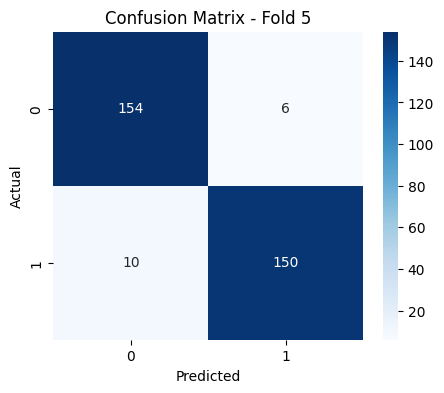

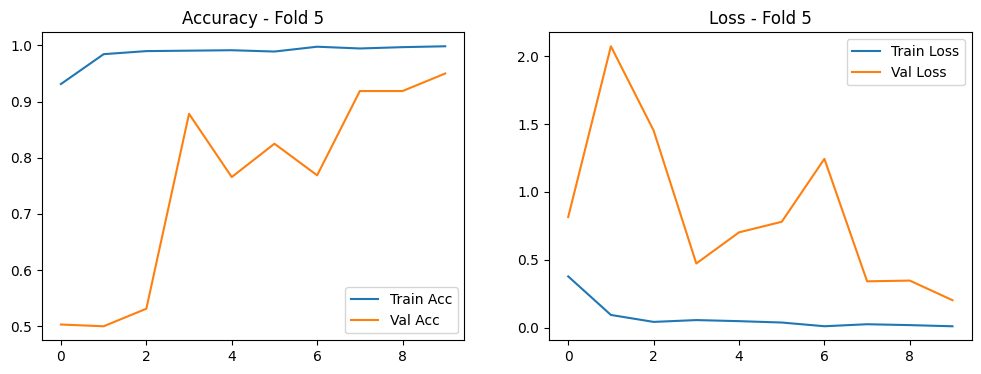


FINAL RESULTS
Mean Accuracy: 0.954375
Std Deviation: 0.0042389562394533


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# =========================
# LOAD DATA
# =========================
dataset_path = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/train"

X = []
y = []

IMG_SIZE = 224

class_names = os.listdir(dataset_path)

for label, class_name in enumerate(class_names):
    class_folder = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)

# =========================
# K-FOLD SETUP
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# MODEL FUNCTION
# =========================
def create_model():

    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# =========================
# K-FOLD TRAINING
# =========================
fold_no = 1
acc_list = []

for train_idx, val_idx in skf.split(X, y):

    print(f"\n🔥 Fold {fold_no}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = create_model()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    # =========================
    # EVALUATION
    # =========================
    y_pred_prob = model.predict(X_val)
    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_val, y_pred)
    acc_list.append(acc)

    print(f"\nFold {fold_no} Accuracy: {acc}")

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - Fold {fold_no}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =========================
    # PLOT LOSS & ACCURACY
    # =========================
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'Accuracy - Fold {fold_no}')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss - Fold {fold_no}')
    plt.legend()

    plt.show()

    fold_no += 1

# =========================
# FINAL RESULT
# =========================
print("\n==============================")
print("FINAL RESULTS")
print("==============================")
print("Mean Accuracy:", np.mean(acc_list))
print("Std Deviation:", np.std(acc_list))
print("==============================")

Found 6000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,073 (98.49 MB)

 Trainable params: 25,817,857 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 156s 781ms/step - accuracy: 0.9687 - loss: 0.1164 - val_accuracy: 0.5000 - val_loss: 1.1700
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 140s 747ms/step - accuracy: 0.9848 - loss: 0.0607 - val_accuracy: 0.5250 - val_loss: 0.6859
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 121s 645ms/step - accuracy: 0.9898 - loss: 0.0405 - val_accuracy: 0.9950 - val_loss: 0.0255
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 655ms/step - accuracy: 0.9882 - loss: 0.0381 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 118s 630ms/step - accuracy: 0.9907 - loss: 0.0353 - val_accuracy: 0.9850 - val_loss: 0.0242
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 119s 635ms/step - accuracy: 0.9912 - loss: 0.0311 - val_accuracy: 0.9950 - val_loss: 0.0232
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 119s 633ms/step - accuracy: 0.9937 - loss: 0.0242 - val_accuracy: 0.9950 - val_loss: 0.0167
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 121s 644ms/step - accuracy: 0.9928 -

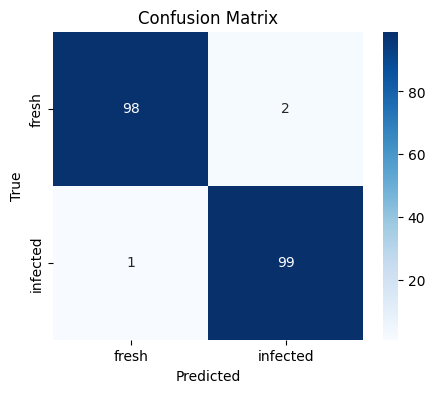


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9899    0.9800    0.9849       100
    infected     0.9802    0.9900    0.9851       100

    accuracy                         0.9850       200
   macro avg     0.9850    0.9850    0.9850       200
weighted avg     0.9850    0.9850    0.9850       200


🔹 Overall Test Accuracy: 0.9850


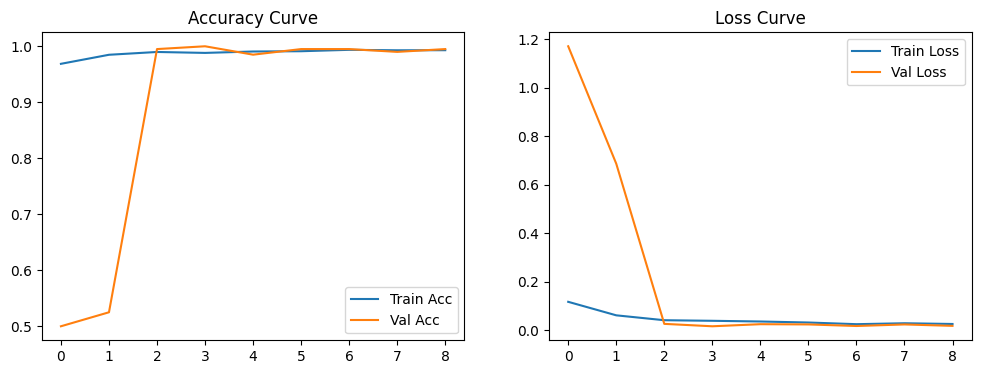

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =========================
# DATA PATHS (YOUR ORIGINAL)
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32
epochs = 10

# =========================
# AUGMENTATION (ONLY TRAIN)
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# =========================
# DATA GENERATORS
# =========================
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# MODEL (SAME AS YOUR STRUCTURE)
# =========================
model_cnn = Sequential([

    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# =========================
# COMPILE
# =========================
model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# =========================
# PREDICTION
# =========================
y_pred = model_cnn.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 Overall Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()

Found 6000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


Model: "functional_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,89

 Total params: 14,881,089 (56.77 MB)

 Trainable params: 165,377 (646.00 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 146s 742ms/step - accuracy: 0.5193 - loss: 1.4649 - val_accuracy: 0.5500 - val_loss: 1.1445
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 132s 700ms/step - accuracy: 0.6280 - loss: 1.2297 - val_accuracy: 0.8750 - val_loss: 0.9361
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 132s 704ms/step - accuracy: 0.7280 - loss: 1.0690 - val_accuracy: 0.9850 - val_loss: 0.8154
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 128s 680ms/step - accuracy: 0.7853 - loss: 0.9582 - val_accuracy: 1.0000 - val_loss: 0.7372
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 130s 690ms/step - accuracy: 0.8348 - loss: 0.8816 - val_accuracy: 1.0000 - val_loss: 0.6813
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 127s 675ms/step - accuracy: 0.8692 - loss: 0.8179 - val_accuracy: 1.0000 - val_loss: 0.6411
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 124s 659ms/step - accuracy: 0.8893 - loss: 0.7751 - val_accuracy: 1.0000 - val_loss: 0.6119
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 636ms/step - accuracy: 0.9198 -

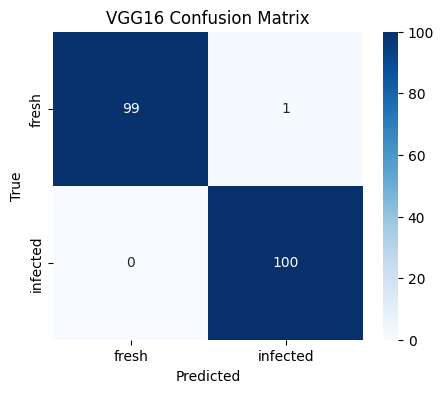


VGG16 Classification Report:

              precision    recall  f1-score   support

       fresh     1.0000    0.9900    0.9950       100
    infected     0.9901    1.0000    0.9950       100

    accuracy                         0.9950       200
   macro avg     0.9950    0.9950    0.9950       200
weighted avg     0.9950    0.9950    0.9950       200


🔹 VGG16 Test Accuracy: 0.9950


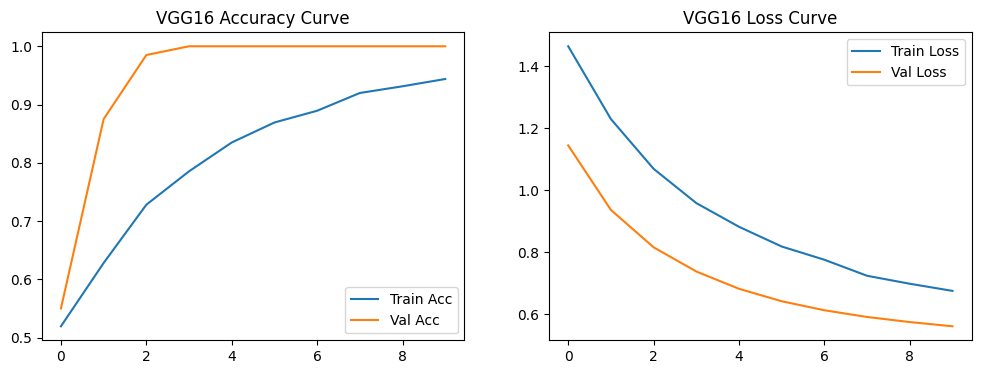

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA PATHS
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32

# =========================
# DATA GENERATORS (FIXED AUGMENTATION)
# =========================
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# VGG16 MODEL (OVERFITTING CONTROLLED)
# =========================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.6)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

# =========================
# COMPILE (LOWER LR FIX)
# =========================
model_vgg16.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg16.summary()

# =========================
# CALLBACKS (IMPROVED)
# =========================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_vgg16.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

# =========================
# TRAINING
# =========================
history_vgg16 = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# =========================
# PREDICTION
# =========================
y_pred = model_vgg16.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nVGG16 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 VGG16 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_vgg16.history['accuracy'], label='Train Acc')
plt.plot(history_vgg16.history['val_accuracy'], label='Val Acc')
plt.title("VGG16 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg16.history['loss'], label='Train Loss')
plt.plot(history_vgg16.history['val_loss'], label='Val Loss')
plt.title("VGG16 Loss Curve")
plt.legend()

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =========================
# DATA PATHS
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32
epochs = 10

# =========================
# AUGMENTATION (ONLY TRAIN)
# =========================
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# =========================
# DATA GENERATORS
# =========================
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# VGG16 MODEL
# =========================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

model_vgg16.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg16.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_vgg16.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# =========================
# PREDICTION
# =========================
y_pred = model_vgg16.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nVGG16 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 VGG16 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("VGG16 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("VGG16 Loss Curve")
plt.legend()

plt.show()

Found 6000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


Model: "functional_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,190,785 (77.02 MB)

 Trainable params: 165,377 (646.00 KB)

 Non-trainable params: 20,025,408 (76.39 MB)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 137s 703ms/step - accuracy: 0.8870 - loss: 0.2928 - val_accuracy: 0.9900 - val_loss: 0.2740
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 126s 665ms/step - accuracy: 0.9783 - loss: 0.0832 - val_accuracy: 0.9950 - val_loss: 0.0551
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 125s 667ms/step - accuracy: 0.9853 - loss: 0.0478 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 118s 628ms/step - accuracy: 0.9917 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 118s 626ms/step - accuracy: 0.9917 - loss: 0.0255 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 124s 658ms/step - accuracy: 0.9917 - loss: 0.0278 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 122s 645ms/step - accuracy: 0.9932 - loss: 0.0211 - val_accuracy: 1.0000 - val_loss: 8.7983e-04
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 636ms/step - accuracy: 0.99

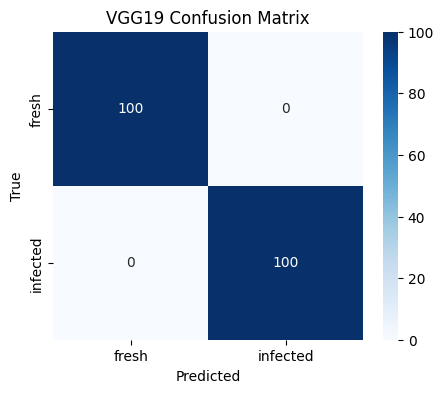


VGG19 Classification Report:

              precision    recall  f1-score   support

       fresh     1.0000    1.0000    1.0000       100
    infected     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200


🔹 VGG19 Test Accuracy: 1.0000


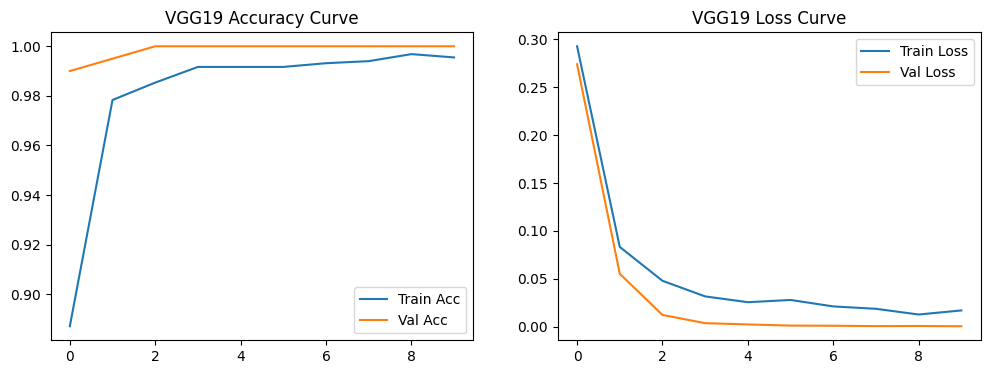

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA PATHS
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32

# =========================
# DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# VGG19 BASE MODEL
# =========================
base_model = VGG19(weights='imagenet',
                   include_top=False,
                   input_shape=(224,224,3))

base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg19 = Model(inputs=base_model.input, outputs=output)

model_vgg19.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_vgg19.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history_vgg19 = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# =========================================================
# 🔥 EVALUATION SECTION (CNN STYLE SAME AS YOUR CODE)
# =========================================================

# =========================
# PREDICTION
# =========================
y_pred = model_vgg19.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("VGG19 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nVGG19 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 VGG19 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_vgg19.history['accuracy'], label='Train Acc')
plt.plot(history_vgg19.history['val_accuracy'], label='Val Acc')
plt.title("VGG19 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg19.history['loss'], label='Train Loss')
plt.plot(history_vgg19.history['val_loss'], label='Val Loss')
plt.title("VGG19 Loss Curve")
plt.legend()

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA PATHS
# =========================
train_dir = "/content/Drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32

# =========================
# DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# RESNET50 BASE MODEL
# =========================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_resnet50 = Model(inputs=base_model.input, outputs=output)

model_resnet50.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_resnet50.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet50.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history_resnet50 = model_resnet50.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# =========================================================
# 🔥 EVALUATION (SAME STYLE AS CNN / VGG)
# =========================================================

# =========================
# PREDICTION
# =========================
y_pred = model_resnet50.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nResNet50 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 ResNet50 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_resnet50.history['accuracy'], label='Train Acc')
plt.plot(history_resnet50.history['val_accuracy'], label='Val Acc')
plt.title("ResNet50 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet50.history['loss'], label='Train Loss')
plt.plot(history_resnet50.history['val_loss'], label='Val Loss')
plt.title("ResNet50 Loss Curve")
plt.legend()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Drive/MyDrive/Chickpea Resources/Dataset_augmented/train'

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA PATHS
# =========================
train_dir = "/content/Drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32

# =========================
# DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# EFFICIENTNETB0 BASE MODEL
# =========================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze pretrained backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_effnetb0 = Model(inputs=base_model.input, outputs=output)

model_effnetb0.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_effnetb0.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_effnetb0.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history_effnetb0 = model_effnetb0.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# =========================================================
# 🔥 EVALUATION SECTION (SAME AS CNN / VGG / RESNET)
# =========================================================

# =========================
# PREDICTION
# =========================
y_pred = model_effnetb0.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nEfficientNetB0 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 EfficientNetB0 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_effnetb0.history['accuracy'], label='Train Acc')
plt.plot(history_effnetb0.history['val_accuracy'], label='Val Acc')
plt.title("EfficientNetB0 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_effnetb0.history['loss'], label='Train Loss')
plt.plot(history_effnetb0.history['val_loss'], label='Val Loss')
plt.title("EfficientNetB0 Loss Curve")
plt.legend()

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# DATA PATHS
# =========================
train_dir = "/content/Drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/Drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32

# =========================
# DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# DENSENET121 BASE MODEL
# =========================
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_densenet121 = Model(inputs=base_model.input, outputs=output)

model_densenet121.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_densenet121.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_densenet121.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history_densenet121 = model_densenet121.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# =========================================================
# 🔥 EVALUATION SECTION (SAME STYLE AS ALL MODELS)
# =========================================================

# =========================
# PREDICTION
# =========================
y_pred = model_densenet121.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nDenseNet121 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 DenseNet121 Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_densenet121.history['accuracy'], label='Train Acc')
plt.plot(history_densenet121.history['val_accuracy'], label='Val Acc')
plt.title("DenseNet121 Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_densenet121.history['loss'], label='Train Loss')
plt.plot(history_densenet121.history['val_loss'], label='Val Loss')
plt.title("DenseNet121 Loss Curve")
plt.legend()

plt.show()

Found 6000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,073 (98.49 MB)

 Trainable params: 25,817,857 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 140s 700ms/step - accuracy: 0.9678 - loss: 0.1096 - val_accuracy: 0.5000 - val_loss: 1.6585
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 130s 687ms/step - accuracy: 0.9857 - loss: 0.0573 - val_accuracy: 0.5900 - val_loss: 0.8050
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 126s 671ms/step - accuracy: 0.9877 - loss: 0.0479 - val_accuracy: 0.9950 - val_loss: 0.0213
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 119s 632ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9950 - val_loss: 0.0205
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 637ms/step - accuracy: 0.9885 - loss: 0.0393 - val_accuracy: 0.9950 - val_loss: 0.0115
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 118s 628ms/step - accuracy: 0.9925 - loss: 0.0271 - val_accuracy: 0.9950 - val_loss: 0.0109
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 636ms/step - accuracy: 0.9923 - loss: 0.0263 - val_accuracy: 0.9950 - val_loss: 0.0108
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 636ms/step - accuracy: 0.9933 -

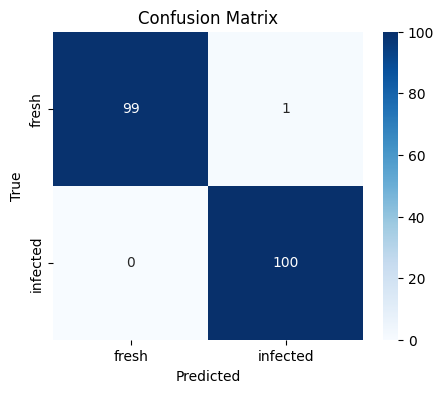


Classification Report:

              precision    recall  f1-score   support

       fresh     1.0000    0.9900    0.9950       100
    infected     0.9901    1.0000    0.9950       100

    accuracy                         0.9950       200
   macro avg     0.9950    0.9950    0.9950       200
weighted avg     0.9950    0.9950    0.9950       200


🔹 Overall Test Accuracy: 0.9950


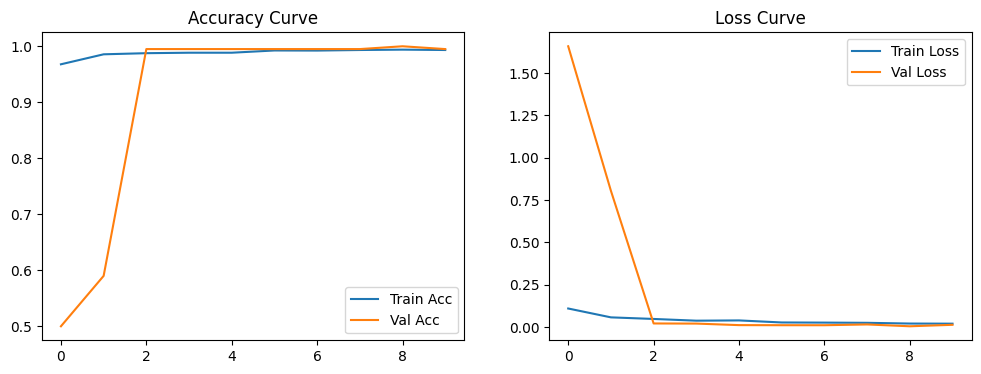

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =========================
# DATA PATHS (YOUR ORIGINAL)
# =========================
train_dir = "/content/drive/MyDrive/Chickpea Resources/Dataset_augmented/train"
val_dir   = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/val"
test_dir  = "/content/drive/MyDrive/Chickpea Resources/Dataset_split/test"

img_size = (224, 224)
batch_size = 32
epochs = 10

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# =========================
# DATA GENERATORS
# =========================
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# =========================
# MODEL (SAME AS YOUR STRUCTURE)
# =========================
model_cnn = Sequential([

    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# =========================
# COMPILE
# =========================
model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True)
]

# =========================
# TRAINING
# =========================
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# =========================
# PREDICTION
# =========================
y_pred = model_cnn.predict(test_gen)

y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# =========================
# ACCURACY
# =========================
overall_acc = np.mean(y_true == y_pred_classes)
print(f"\n🔹 Overall Test Accuracy: {overall_acc:.4f}")

# =========================
# TRAINING CURVES
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()